In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.763995,-1.609605,-1.585030,-1.257179,1.362324,0
1,0.445063,-1.296327,-0.805847,3.338797,2.116663,1
2,0.672734,0.077762,-0.585476,-1.390132,1.071951,0
3,0.633634,-2.314616,-0.132584,0.609656,1.174103,1
4,-0.113653,0.474276,0.567232,2.013449,0.041351,1


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
import random
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipython-input-4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [8]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipython-input-4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipython-input-4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col4', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')
Index(['col5', 'col1', 'target'], dtype='object')


In [11]:
df3

,col5,col1,target
51,-0.958691,0.359559,0
92,-1.311481,2.653572,0
17,2.600208,0.088916,1
94,1.034989,1.426413,1
42,0.979585,-2.650497,1
84,2.760490,0.118885,1
50,1.633360,-0.615547,0
7,2.502427,-0.807769,0
42,0.979585,-2.650497,1
59,0.055772,1.275257,0


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [14]:
from sklearn.tree import plot_tree

[Text(0.5416666666666666, 0.9545454545454546, 'x[1] <= 0.851\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3333333333333333, 0.8636363636363636, 'x[1] <= -2.062\ngini = 0.411\nsamples = 38\nvalue = [27, 11]'),
 Text(0.4375, 0.9090909090909092, 'True  '),
 Text(0.25, 0.7727272727272727, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4166666666666667, 0.7727272727272727, 'x[0] <= -0.161\ngini = 0.353\nsamples = 35\nvalue = [27, 8]'),
 Text(0.25, 0.6818181818181818, 'x[0] <= -0.498\ngini = 0.444\nsamples = 21\nvalue = [14, 7]'),
 Text(0.16666666666666666, 0.5909090909090909, 'x[1] <= -1.439\ngini = 0.388\nsamples = 19\nvalue = [14, 5]'),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.5, 'x[1] <= -1.428\ngini = 0.473\nsamples = 13\nvalue = [8, 5]'),
 Text(0.16666666666666666, 0.4090909090909091, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.4090909090909091, 'x[0] <= -1.851\ngini = 0.397\nsamples = 11\

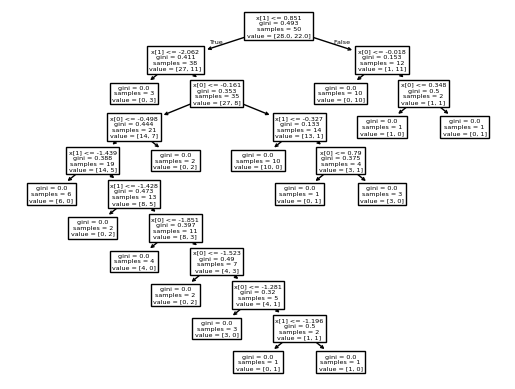

In [15]:
plot_tree(clf1)

[Text(0.5, 0.9, 'x[0] <= 0.57\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3, 0.7, 'x[1] <= -1.248\ngini = 0.091\nsamples = 21\nvalue = [1, 20]'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[0] <= -0.028\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.7, 0.7, 'x[1] <= -2.365\ngini = 0.285\nsamples = 29\nvalue = [24, 5]'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.5, 'x[0] <= 1.52\ngini = 0.142\nsamples = 26\nvalue = [24, 2]'),
 Text(0.7, 0.3, 'x[0] <= 1.361\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]')]

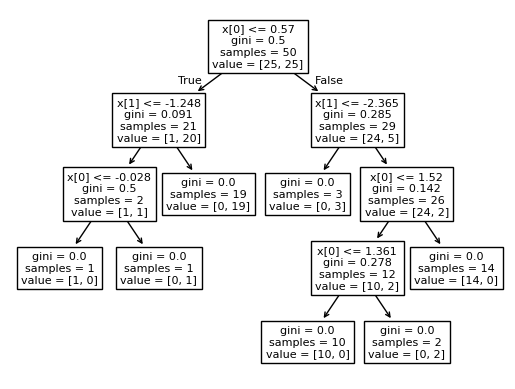

In [16]:
plot_tree(clf2)

[Text(0.5138888888888888, 0.9285714285714286, 'x[1] <= 0.864\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.25, 0.7857142857142857, 'x[1] <= -0.968\ngini = 0.457\nsamples = 34\nvalue = [12, 22]'),
 Text(0.3819444444444444, 0.8571428571428572, 'True  '),
 Text(0.1111111111111111, 0.6428571428571429, 'x[0] <= 3.538\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.05555555555555555, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3888888888888889, 0.6428571428571429, 'x[1] <= -0.32\ngini = 0.499\nsamples = 23\nvalue = [11, 12]'),
 Text(0.2777777777777778, 0.5, 'x[0] <= 0.432\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.2222222222222222, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.35714285714285715, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.5, 0.5, 'x[0] <= 1.93\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.444

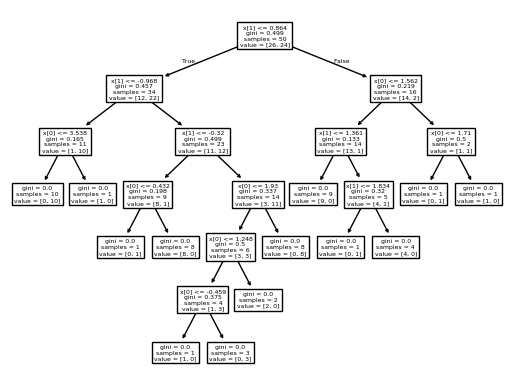

In [17]:
plot_tree(clf3)

In [18]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [19]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [20]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [21]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
72,-1.461139,-1.594652,0.551153,2.754371,1.569136,1
72,-1.461139,-1.594652,0.551153,2.754371,1.569136,1
97,-1.441507,-0.749765,-1.833924,-1.977092,3.861977,0
57,-0.574344,0.444982,1.365474,-2.182846,1.991572,1
9,0.833730,-2.328393,-2.031745,-1.689798,1.959504,0
38,-0.008107,0.609806,0.397798,-0.248619,1.188285,1
28,-0.946811,0.868067,0.424032,-1.305325,1.285194,0
78,-1.504815,-0.646351,1.651728,1.295231,0.188927,1
48,0.611821,-0.484652,0.918875,-1.661242,1.129507,1
75,2.241233,0.054268,-3.676852,1.559222,-1.671083,0
